In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana/saltandpepper_Screen Shot 2018-06-12 at 8.53.54 PM.png
/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana/Screen Shot 2018-06-12 at 9.27.26 PM.png
/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana/rotated_by_45_Screen Shot 2018-06-12 at 8.58.13 PM.png
/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana/rotated_by_75_Screen Shot 2018-06-12 at 8.47.41 PM.png
/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana/rotated_by_75_Screen Shot 2018-06-12 at 8.56.30 PM.png
/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana/saltandpepper_Screen Shot 2018-06-12 at 9.11.17 PM.png
/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana/vertical_flip_Screen Shot 2018-06-12 at 9.19.08

In [2]:
#paths
trPath = "/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset/train"
tsPath = "/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset/test"


In [3]:
#imports
import torch
import cv2
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

In [4]:
tr_imgs = datasets.ImageFolder(root=trPath)
len(tr_imgs)

10901

In [6]:
tr_imgs.samples[1]

('/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset/train/freshapples/Screen Shot 2018-06-08 at 4.59.49 PM.png',
 0)

In [5]:
#augumentations
import cv2
import numpy as np
import random

def random_rotate(image, angle_range=(-25,25)):
    angle = random.uniform(*angle_range)
    h,w = image.shape[:2]
    M = cv2.getRotationMatrix2D((w//2,h//2), angle, 1)
    return cv2.warpAffine(image, M, (w,h), borderMode=cv2.BORDER_REFLECT_101)

def random_flip(image):
    if random.random()<0.5:
        return cv2.flip(image, 1)
    return(image)

def random_brightness(image, factor_range=(0.6,1.4)):
    factor = random.uniform(*factor_range)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hsv = hsv.astype(np.float32)
    hsv[:,:,2] = hsv[:,:,2]*factor
    hsv[:,:,2] = np.clip(hsv[:,:,2], 0 , 255)
    hsv = hsv.astype(np.uint8)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

def random_zoom(image, zoom_range=(0.8, 1.2)):
    zoom_factor = random.uniform(*zoom_range)
    h,w = image.shape[:2]

    if zoom_factor>1:
        new_h, new_w = int(h/zoom_factor), int(w/zoom_factor)
        y1 = (h - new_h)//2
        x1 = (w - new_w)//2
        cropped = image[y1:y1+new_h, x1:x1+new_w]
        return cv2.resize(cropped, (w,h))
    else:
        new_h, new_w = int(h*zoom_factor), int(w*zoom_factor)
        resized = cv2.resize(image, (new_w, new_h))
        pad_y = (h-new_h)//2
        pad_x = (w-new_w)//2
        padded = cv2.copyMakeBorder(resized, pad_y, h-new_h-pad_y, pad_x, w-new_w-pad_x, cv2.BORDER_REFLECT_101)
        return padded


def random_shift(image, shift_range=0.2):
    h,w = image.shape[:2]
    max_dx = w*shift_range
    max_dy = h*shift_range

    dx = random.uniform(-max_dx, max_dx)
    dy = random.uniform(-max_dy, max_dy)
    M = np.float32([[1,0, dx], [0,1,dy]])
    return cv2.warpAffine(image, M, (w,h), borderMode=cv2.BORDER_REFLECT_101)

def random_blur(image, ksize=(3,5)):
    if random.random()<0.3:
        k = random.choice(ksize)
        return cv2.GaussianBlur(image, (k,k), 0)
    return image

def random_noise(image):
    if random.random()<0.3:
        noise = np.random.normal(0,10, image.shape).astype(np.int16)
        noisy = image.astype(np.int16) + noise
        return np.clip(noisy, 0, 255).astype(np.uint8)
    return image


def augment_image(image):
    image = random_rotate(image)
    image = random_flip(image)
    image = random_brightness(image)
    image = random_zoom(image)
    image = random_shift(image)
    image = random_blur(image)
    image = random_noise(image)

In [6]:
class FruitDataset(Dataset):
    def __init__(self, data, augment=False, image_size=224):
        #self.data = datasets.ImageFolder(root_dir)
        self.data = data
        self.samples = data.samples
        #self.indices = data.indices
        self.augment = augment
        self.image_size = image_size
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                             std = [0.229, 0.224, 0.225])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        #idx = self.indices[idx]
        #img_path, label = self.samples[idx]

        #img_path, label = self.data[idx]
        img_path, label = self.samples[idx]
        image = cv2.imread(img_path)
        #print(image)
        if image is None:
            raise RuntimeError(f"Failed to Load the Image{img_path}")
        
        image = cv2.resize(image, (self.image_size, self.image_size))
        
        if self.augment:
            image = augment_image(image)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = image.astype(np.float32)/255

        image = np.transpose(image, (2,0,1))

        image = torch.from_numpy(image)
        image = self.normalize(image)
        
        return(image, label)

In [8]:
train_data = datasets.ImageFolder(root=trPath)

full_dataset = FruitDataset(train_data, augment=True)

#Creating Datasets
train_size = int(0.9*len(full_dataset))
val_size = len(train_data) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_dataset.dataset.augment = True
val_dataset.dataset.augment = False

#Dataloaders
train_loader = DataLoader(train_dataset, batch_size=24, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=24, shuffle=False, num_workers=4, pin_memory=True)


In [15]:
train_dataset[0]

(tensor([[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          ...,
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],
 
         [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          ...,
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],
 
         [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
          [-1.8044, -1.8044,

In [8]:
class NormalConvModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.clayer = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            
            nn.Linear(256, 150),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(150,6)
        )

    def forward(self, x):
        x = self.clayer(x)
        return x
    
    

In [ ]:
class MultiConvModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.Conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            #nn.BatchNorm2d(256),
            #nn.ReLU(inplace=True),
            #nn.MaxPool2d(kernel_size=2, stride=2),

            #nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            #nn.BatchNorm2d(256),
            #nn.ReLU(inplace=True),
            #nn.MaxPool2d(kernel_size=2, stride=2),"""

            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten()
        )

        self.Conv2 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            #nn.BatchNorm2d(256),
            #nn.ReLU(inplace=True),
            #nn.MaxPool2d(kernel_size=2, stride=2),

            #nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            #nn.BatchNorm2d(256),
            #nn.ReLU(inplace=True),
            #nn.MaxPool2d(kernel_size=2, stride=2),

            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten()
        )
        self.Conv3 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            #nn.BatchNorm2d(256),
            #nn.ReLU(inplace=True),
            #nn.MaxPool2d(kernel_size=2, stride=2),

            #nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            #nn.BatchNorm2d(256),
            #nn.ReLU(inplace=True),
            #nn.MaxPool2d(kernel_size=2, stride=2),

            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten()
        )
        self.FFlayer = nn.Sequential(
            nn.Linear(384, 384),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(384,6)
        )

    def forward(self, x):
        x1 = self.Conv1(x)
        x2 = self.Conv2(x)
        x3 = self.Conv3(x)
        #print(x1.shape)
        x_cat = torch.cat((x1,x2,x3), dim=1)
        #print(x_cat.shape)
        x = self.FFlayer(x_cat)
        return x
    
    

In [9]:
class TreeCnn(nn.Module):
    def __init__(self):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.branch1 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            #nn.MaxPool2d(kernel_size=2, stride=2),
            #nn.AdaptiveAvgPool2d((1,1)),

            #nn.Flatten()
        )
        self.branch2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=5, padding=2, stride=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, kernel_size=5, padding=2, stride=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            #nn.MaxPool2d(kernel_size=2, stride=2),
            #nn.AdaptiveAvgPool2d((1,1)),

            #nn.Flatten()
        )
        self.branch3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=7, padding=3, stride=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, kernel_size=7, padding=3, stride=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            #nn.MaxPool2d(kernel_size=2, stride=2),
            #nn.AdaptiveAvgPool2d((1,1)),

            #nn.Flatten()
        )

        self.head = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(256*3, 300),
            #nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Linear(300, 6)
            #nn.Linear(256,6)
        )
    def forward(self, x):
        x = self.stem(x)
        x1 = self.branch1(x)
        x2 = self.branch2(x)
        x3 = self.branch3(x)

        x = torch.cat([x1,x2,x3], dim=1)
        #x = x1+x2+x3

        x = self.head(x)
        return x

In [12]:
#accuracy

def accuracy(preds, labels):
    #values, indx = torch.max(preds, dim=1)
    _, indx = torch.max(preds, dim=1)
    #accuracy = (indx==labels).sum().item()/len(labels)
    accuracy = (indx==labels).sum().item()
    return accuracy
#training loop

def training_loop(model, dataloader, optimizer, loss_func, device):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    
    for images, labels in tqdm(dataloader, desc="Training"):
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = model(images)
        loss = loss_func(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss = running_loss + loss.item()
        running_acc = running_acc + accuracy(outputs, labels)
        
    epoch_loss = running_loss/len(dataloader)
    epoch_acc = running_acc/len(dataloader.dataset)
    return(epoch_loss, epoch_acc)

#validation loop
def validation_loop(model, dataloader,loss_func, device):
    model.eval()
    running_loss = 0.0
    running_acc = 0.0

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_func(outputs, labels)
    
            running_loss += loss.item()
            running_acc += accuracy(outputs, labels)
    
    epoch_loss = running_loss/len(dataloader)
    epoch_acc = running_acc/len(dataloader.dataset)
    return(epoch_loss, epoch_acc)
    

In [14]:
#Full Traning Loop

def train_model(model, train_loader, val_loader, epochs, learning_rate=1e-4,device='cuda'):
    model.to(device)

    loss_func = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    best_val_acc = 0.0

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        train_loss, train_acc = training_loop(model, train_loader, optimizer, loss_func, device)
        val_loss, val_acc = validation_loop(model, val_loader, loss_func, device)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:{val_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_model.pth")
    print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [22]:
model1 = NormalConvModel()

train_model(model=model1, train_loader=train_loader, val_loader=val_loader, epochs=20, learning_rate=1e-4, device=device)


Epoch 1/20


Validation: 100%|██████████| 46/46 [00:02<00:00, 16.03it/s]


Train Loss: 0.7536 | Train Acc: 0.7874
Val Loss:0.4117 | Val Acc: 0.8708

Epoch 2/20


Validation: 100%|██████████| 46/46 [00:02<00:00, 16.20it/s]


Train Loss: 0.4214 | Train Acc: 0.8638
Val Loss:0.2815 | Val Acc: 0.9074

Epoch 3/20


...

Train Loss: 0.0812 | Train Acc: 0.9741
Val Loss:0.0873 | Val Acc: 0.9670

Epoch 19/20


Validation: 100%|██████████| 46/46 [00:02<00:00, 16.16it/s]


Train Loss: 0.0909 | Train Acc: 0.9689
Val Loss:0.1096 | Val Acc: 0.9569

Epoch 20/20


Validation: 100%|██████████| 46/46 [00:02<00:00, 15.53it/s]

Train Loss: 0.0807 | Train Acc: 0.9730
Val Loss:0.0693 | Val Acc: 0.9725

Best Validation Accuracy: 0.9835


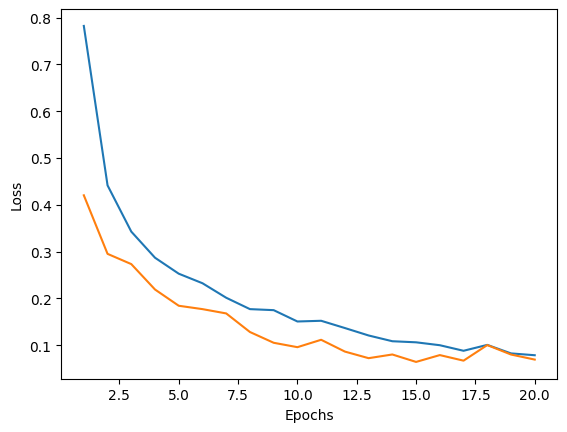

In [6]:
import matplotlib.pyplot as plt

train_losses = [0.7822,0.4415,0.3427,0.2869,0.2528,0.2324,0.2014, 0.1771,0.1749,0.1507,0.1522,0.1367,0.1208,0.1085,0.1062,0.1000,0.0881,0.1007,0.0825,0.0786]
val_losses = [0.4203,0.2952,0.2733,0.2190,0.1843,0.1771,0.1679,0.1282,0.1052,0.0958,0.1116,0.0864,0.0723,0.0802,0.0643,0.0789,0.0670,0.1003,0.0801,0.0693]
epochs = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
plt.plot(epochs,train_losses)
plt.plot(epochs,val_losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [23]:
model2 = TreeCnn()

train_model(model=model2, train_loader=train_loader, val_loader=val_loader, epochs=20, learning_rate=1e-4, device=device)


Epoch 1/20


Validation: 100%|██████████| 46/46 [00:05<00:00,  8.91it/s]


Train Loss: 0.6227 | Train Acc: 0.8042
Val Loss:0.4172 | Val Acc: 0.8506

Epoch 2/20


Validation: 100%|██████████| 46/46 [00:05<00:00,  8.90it/s]


Train Loss: 0.3120 | Train Acc: 0.8903
Val Loss:0.2383 | Val Acc: 0.9212

Epoch 4/20


...

Train Loss: 0.0991 | Train Acc: 0.9651
Val Loss:0.0731 | Val Acc: 0.9789

Epoch 19/20


Validation: 100%|██████████| 46/46 [00:05<00:00,  8.91it/s]


Train Loss: 0.1032 | Train Acc: 0.9620
Val Loss:0.0856 | Val Acc: 0.9652

Epoch 20/20


Validation: 100%|██████████| 46/46 [00:05<00:00,  8.91it/s]


Train Loss: 0.0930 | Train Acc: 0.9667
Val Loss:0.0642 | Val Acc: 0.9798

Best Validation Accuracy: 0.9798


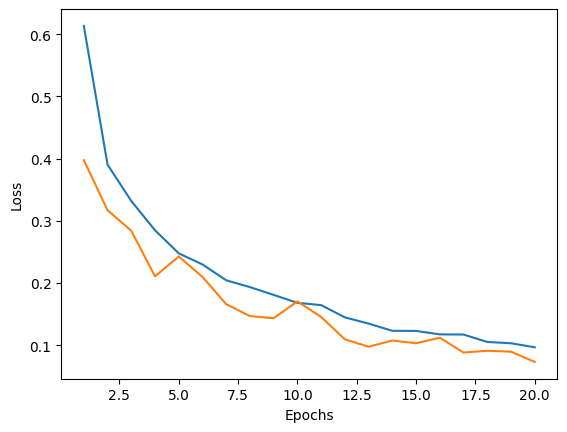

In [7]:
train_losses = [0.6133,0.3903,0.3319,0.2848,0.2477,0.2299,0.2044,0.1935, 0.1809,0.1682,0.1645,0.1448,0.1348,0.1232,0.1230,0.1175,0.1172,0.1053,0.1032,0.0967]
val_losses = [0.3976,0.3171,0.2839,0.2108,0.2427,0.2098,0.1660,0.1469,0.1435,0.1705,0.1455,0.1095,0.0976,0.1076,0.1032,0.1121,0.0883,0.0911,0.0897,0.0732]
epochs = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
plt.plot(epochs,train_losses)
plt.plot(epochs,val_losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [27]:
#testing
test_data = datasets.ImageFolder(root=tsPath)
test_dataset = FruitDataset(test_data, augment=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

#img, label = test_dataset[0]
#print(img, label)

#img = img.unsqueeze(0)
#img = img.to(device)

#model = NormalConvModel().to(device)

#outputs = model(img)
#print(outputs)
#probs = torch.softmax(outputs, dim=1)
#print(probs)       

def testing(test_loader, model):
    correct_preds = 0.0
    #acc = 0.0
    model.eval()
    model.to(device)
    with torch.no_grad():
        for imgs, labels in tqdm(test_loader, desc="Testing"):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            correct_preds += accuracy(outputs, labels)
        acc = correct_preds/len(test_dataset)
    return acc
    

In [18]:
model1 = NormalConvModel()
state_dict = torch.load("/kaggle/input/models/codingbabloo/normal-conv-model/pytorch/default/1/normal_conv_model.pth", map_location='cpu')
model1.load_state_dict(state_dict=state_dict)
model1.eval()

NormalConvModel(
  (clayer): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=

In [20]:
model1_acc_score = testing(test_loader, model1)
model1_acc_score*100

Testing: 100%|██████████| 85/85 [00:07<00:00, 11.33it/s]


97.59080800593031

In [21]:
model2 = TreeCnn()
state_dict = torch.load('/kaggle/input/models/codingbabloo/treecnn/pytorch/default/1/TreeCnn_Model.pth', map_location='cpu')
model2.load_state_dict(state_dict=state_dict)
model2.eval()

TreeCnn(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (branch1): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (branch2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 256, kernel_size=(5, 5), stride=

In [22]:
model2_acc_score = testing(test_loader, model2)
model2_acc_score*100

Testing: 100%|██████████| 85/85 [00:10<00:00,  7.81it/s]


98.18383988139362

In [33]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt



def get_report(model, test_loader):
    model.eval()
    classes = tr_imgs.classes
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
    
            images = images.to(device)
            labels = labels.to(device)
    
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
    
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        
        print(classification_report(all_labels, all_preds, target_names=classes))

    
        cm = confusion_matrix(all_labels, all_preds)
        
        plt.figure(figsize=(8,6))
        sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=classes, yticklabels=classes)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()



               precision    recall  f1-score   support

  freshapples       0.95      0.99      0.97       395
  freshbanana       1.00      1.00      1.00       381
 freshoranges       0.95      0.99      0.97       388
 rottenapples       0.99      0.93      0.96       601
 rottenbanana       1.00      0.99      1.00       530
rottenoranges       0.96      0.97      0.96       403

     accuracy                           0.98      2698
    macro avg       0.97      0.98      0.98      2698
 weighted avg       0.98      0.98      0.98      2698



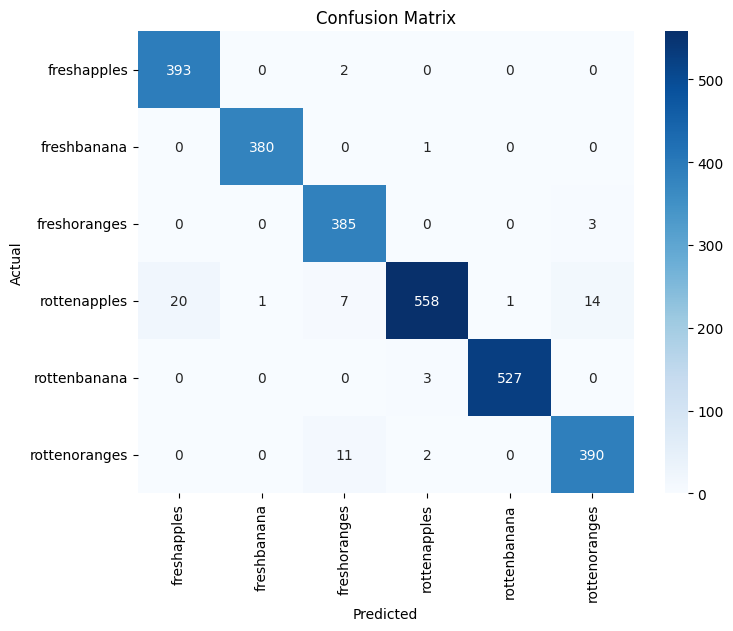

In [34]:
get_report(model1, test_loader)

               precision    recall  f1-score   support

  freshapples       0.97      0.98      0.98       395
  freshbanana       1.00      1.00      1.00       381
 freshoranges       0.98      0.97      0.98       388
 rottenapples       0.98      0.96      0.97       601
 rottenbanana       0.99      1.00      1.00       530
rottenoranges       0.95      0.98      0.97       403

     accuracy                           0.98      2698
    macro avg       0.98      0.98      0.98      2698
 weighted avg       0.98      0.98      0.98      2698



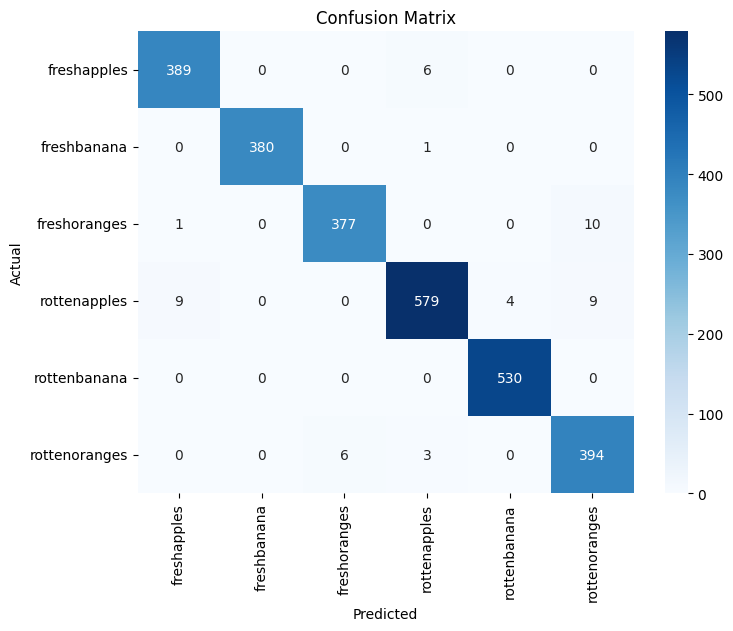

In [35]:
get_report(model2, test_loader)